In [122]:
import micro_sam
import skimage
import os
import matplotlib.pyplot as plt
import numpy as np

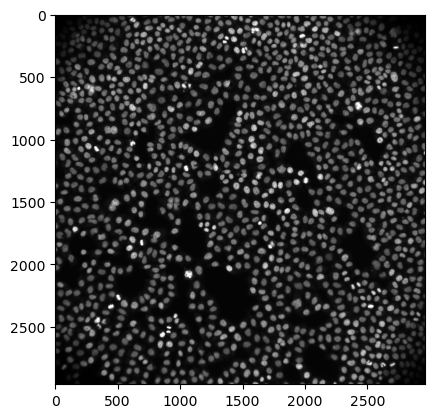

In [139]:
im = skimage.io.imread('/scr/yren/20X_c0-DAPI_A1_Tile-50.phenotype.tif')
plt.imshow(im, cmap='gray')

In [140]:
predictor = micro_sam.util.get_sam_model(model_type="vit_b_lm")
aum = micro_sam.instance_segmentation.AutomaticMaskGenerator(predictor=predictor)

In [ ]:
im = ((im / im.max()) * 255).astype(np.uint8) # min-max normalization does not work
print(np.min(im), np.max(im))

1 255


In [142]:
px = np.concatenate(
        (im[:,:,np.newaxis], im[:,:,np.newaxis], im[:,:,np.newaxis]), 
        axis=2)

In [143]:
print(px.dtype)
px = np.asarray(px, dtype='uint8')
print(px.dtype)
print(px.shape)

uint8
uint8
(2960, 2960, 3)


In [144]:
print(im.dtype)

uint8


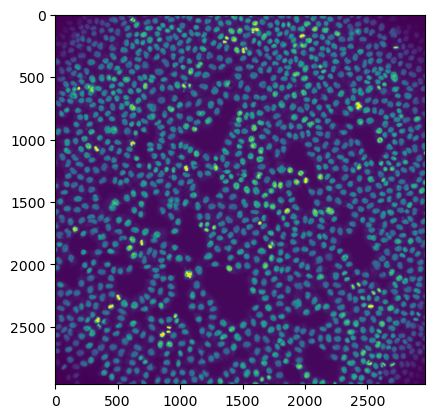

In [145]:
plt.imshow(im)

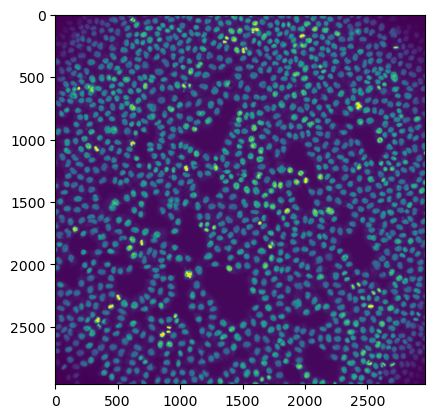

In [148]:
plt.imshow(px[:,:,2])

In [149]:
aum.initialize(image=im)

Compute Image Embeddings 2D: 100%|██████████| 1/1 [00:00<00:00,  4.22it/s]


In [151]:
aum.generate()

[]

In [153]:
predictor.set_image(image=px)

In [155]:
output = predictor.predict()

In [157]:
print(output[0].shape)

(3, 2960, 2960)


In [92]:
# dir(predictor)

In [93]:
print(im.shape)

(2960, 2960)


In [94]:
import numpy as np
import torch

In [95]:
def patch_to_rgb(patch, edges=False):
    if edges:
        sobel = skimage.filters.sobel(patch)
        sobel = 2*skimage.exposure.rescale_intensity(sobel, out_range=np.float32)
        sobel[sobel > 1.] = 1.
    else:
        sobel = patch
        
    px = np.concatenate(
        (sobel[np.newaxis,:,:], patch[np.newaxis,:,:], patch[np.newaxis,:,:]), 
        axis=0)
    return torch.Tensor(px)

In [96]:
# im = np.asarray(im, dtype='uint8')
im = patch_to_rgb(im)
print(im.shape)
print(im.dtype)

torch.Size([3, 2960, 2960])
torch.float32


In [97]:
predictor.set_image(im)